# Detecção de Anomalias em Licitações Públicas de TI
## Pipeline Completo: Pré-processamento → Mineração → Interpretação

---

Este notebook é **autocontido**: executa todas as etapas do processo KDD (Fayyad et al., 1996)
em sequência, desde o carregamento dos arquivos CSV brutos até a exportação dos resultados.

### Etapas implementadas

| Etapa KDD | Seção | O que faz |
|---|---|---|
| Seleção | 1 | Carrega os CSVs dos anos 2020–2025 |
| Pré-processamento | 2 | Limpeza, tipos corretos, tratamento de ausentes |
| Transformação | 3 | Features derivadas (sobrepreço, lead time, flags) |
| Mineração | 4–7 | Isolation Forest + LOF (detecção não-supervisionada) |
| Interpretação | 8 | Score ensemble, perfil das anomalias, gráficos |

### Por que detecção não-supervisionada?

O dataset **não possui rótulos** — não há registros previamente classificados como
fraudulentos ou regulares. Nesse cenário, Chandola, Banerjee e Kumar (2009) indicam
algoritmos que detectam desvios estatísticos sem depender de exemplos rotulados.

A abordagem adotada combina dois algoritmos complementares:

- **Isolation Forest** (Liu, Ting & Zhou, 2008): isola instâncias usando árvores aleatórias.
  Anomalias são raras e diferentes — portanto são isoladas com menos cortes.
  Treinado no dataset **completo** (todos os anos, todas as modalidades) para que o modelo
  aprenda o que é "normal" no universo inteiro de licitações do estado.

- **LOF — Local Outlier Factor** (Breunig et al., 2000): compara a densidade local de cada
  registro com a de seus vizinhos mais próximos. Detecta anomalias **locais** (incomuns
  dentro do próprio contexto de TI), complementando o IF que detecta anomalias **globais**.

### Referências principais

- Fayyad, Piatetsky-Shapiro e Smyth (1996): processo KDD
- Liu, Ting e Zhou (2008): Isolation Forest — IEEE ICDM
- Breunig et al. (2000): LOF — ACM SIGMOD
- Chandola, Banerjee e Kumar (2009): Anomaly Detection Survey — ACM CSUR
- Lundberg e Lee (2017): SHAP — NeurIPS
- Lei 14.133/2021: Nova Lei de Licitações e Contratos Administrativos

---
## 1 — Importações e Configurações Globais

In [10]:
# =============================================================================
# IMPORTAÇÕES
# =============================================================================
# Suprimimos avisos irrelevantes para não poluir a saída do notebook.
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np
from pathlib import Path                          # manipulação de caminhos multiplataforma
from IPython.display import display, FileLink     # exibe tabelas e links no notebook

# Pré-processamento para o modelo de ML
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Algoritmos de detecção de anomalias
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# SHAP: explica individualmente por que cada registro foi considerado anômalo.
# É opcional — o notebook funciona sem ele, mas com interpretabilidade reduzida.
# Para instalar: pip install shap
try:
    import shap
    SHAP_DISPONIVEL = True
    print('✓ SHAP disponível — interpretabilidade por instância ativada')
except ImportError:
    SHAP_DISPONIVEL = False
    print('⚠ SHAP não encontrado (pip install shap para ativar)')
    print('  Será usada análise de desvio por feature como alternativa.')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================
pd.options.display.max_columns  = 50
pd.options.display.max_colwidth = 120
pd.options.display.float_format = lambda x: f'{x:,.2f}'

# Pasta onde os resultados serão salvos
EXPORTS_DIR = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

# Semente aleatória — garante que os resultados sejam reproduzíveis
RANDOM_STATE = 42

print('\nConfiguração concluída.')

✓ SHAP disponível — interpretabilidade por instância ativada

Configuração concluída.


---
## 2 — Seleção dos Dados

Carregamos todos os arquivos CSV disponíveis (um por ano) e os concatenamos em um único
DataFrame. Cada arquivo segue o mesmo layout do portal de licitações do Estado do Paraná:
separador `;`, cabeçalho na primeira linha, valores monetários com vírgula decimal.

Todos os campos são lidos como `str` (string) nesta etapa para evitar conversões automáticas
incorretas — a tipagem correta é feita na etapa seguinte.

In [11]:
# =============================================================================
# CAMINHOS DOS ARQUIVOS
# Adicione ou remova anos conforme a disponibilidade dos dados.
# =============================================================================
csv_paths = [
    Path('./data/TB_LICITACOES-2025.csv'),
    Path('./data/TB_LICITACOES-2024.csv'),
    Path('./data/TB_LICITACOES-2023.csv'),
    Path('./data/TB_LICITACOES-2022.csv'),
    Path('./data/TB_LICITACOES-2021.csv'),
    Path('./data/TB_LICITACOES-2020.csv'),
]

frames = []
for path_csv in csv_paths:
    if not path_csv.exists():
        print(f'  ⚠ Arquivo não encontrado: {path_csv} — ignorado')
        continue

    frame = (
        pd.read_csv(path_csv, sep=';', dtype=str)  # lê tudo como texto para evitar erros
            .rename(columns=str.lower)              # padroniza nomes de colunas em minúsculas
            .assign(arquivo=path_csv.name)          # registra de qual arquivo veio cada linha
    )
    frames.append(frame)
    print(f'  ✓ {path_csv.name}: {len(frame):,} registros')

# Concatena todos os anos em um único DataFrame
raw_df = pd.concat(frames, ignore_index=True)

print(f'\nTotal carregado: {len(raw_df):,} registros  |  {raw_df.shape[1]} colunas')
raw_df.head(3)

  ✓ TB_LICITACOES-2025.csv: 1,732 registros
  ✓ TB_LICITACOES-2024.csv: 2,645 registros
  ✓ TB_LICITACOES-2023.csv: 2,725 registros
  ✓ TB_LICITACOES-2022.csv: 2,708 registros
  ✓ TB_LICITACOES-2021.csv: 2,028 registros
  ✓ TB_LICITACOES-2020.csv: 1,698 registros

Total carregado: 13,536 registros  |  19 colunas


,numprocesso,ano,modalidade,situacao,objeto,orgao,registrodepreco,vigenciaata,revogacaoata,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,localdisputa,idlicitacoes,protocolo,tempoprazocontrato,arquivo
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,Não,NaN,NaN,-,0.00,NaN,2025-02-19,NaN,NaN,NaN,234022687,NaN,TB_LICITACOES-2025.csv
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Não,NaN,NaN,Menor Preço,0.00,NaN,2025-05-22,NaN,NaN,NaN,239262546,1 Parcela(s) - Empreitada/Global,TB_LICITACOES-2025.csv
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Não,NaN,NaN,Menor Preço,0.00,NaN,2025-06-04,NaN,NaN,NaN,239013830,NaN,TB_LICITACOES-2025.csv


---
## 3 — Pré-processamento

Esta etapa transforma os dados brutos em um formato utilizável:

1. **Remoção de colunas irrelevantes** para o escopo desta análise
2. **Conversão de datas** de string para `datetime`
3. **Conversão de valores monetários** de string (formato brasileiro) para `float`
4. **Normalização do texto** descritivo (`objeto`) para facilitar busca por palavras-chave

In [12]:
# =============================================================================
# FUNÇÃO AUXILIAR: conversão de data com tolerância a erros
# =============================================================================
def para_datetime(series, fmt='%Y-%m-%d'):
    """
    Converte uma Series de strings para datetime.
    Strings inválidas ou ausentes viram NaT (Not a Time) em vez de gerar erro.
    """
    return pd.to_datetime(series, format=fmt, errors='coerce')


# =============================================================================
# CÓPIA DO RAW — nunca modificamos o original para poder reprocessar se necessário
# =============================================================================
clean_df = raw_df.copy()

# =============================================================================
# 3.1 — REMOÇÃO DE COLUNAS DESNECESSÁRIAS
# Colunas removidas e motivo:
#   registrodepreco  → informação binária já codificada nas flags de desconto
#   vigenciaata      → relevante apenas para contratos, fora do escopo
#   revogacaoata     → idem
#   localdisputa     → não influencia detecção de anomalias financeiras
#   idlicitacoes     → identificador interno sem valor analítico
#   protocolo        → idem
#   tempoprazocontrato → dado textual não estruturado de difícil padronização
# =============================================================================
colunas_remover = [
    'registrodepreco', 'vigenciaata', 'revogacaoata',
    'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato'
]
clean_df = clean_df.drop(columns=colunas_remover, errors='ignore')

# =============================================================================
# 3.2 — CONVERSÃO DE DATAS
# dataabertura:    data em que o certame foi aberto ao público
# datahomologacao: data em que o resultado foi oficialmente homologado
# =============================================================================
clean_df['dataabertura']    = para_datetime(clean_df['dataabertura'])
clean_df['datahomologacao'] = para_datetime(clean_df['datahomologacao'])

# =============================================================================
# 3.3 — CONVERSÃO DE VALORES MONETÁRIOS
# Os CSVs usam formato brasileiro: ponto como separador de milhar, vírgula como decimal.
# Exemplo: "1.234.567,89" → 1234567.89
# Passo 1: remove os pontos de milhar
# Passo 2: troca a vírgula decimal por ponto
# Passo 3: converte para float (erros viram NaN)
# =============================================================================
for col in ['valor_estimado', 'valor_ou_desconto_homologado']:
    clean_df[col] = (
        clean_df[col]
        .str.replace('.', '', regex=False)   # remove separador de milhar
        .str.replace(',', '.', regex=False)  # troca decimal
    )
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

# =============================================================================
# 3.4 — NORMALIZAÇÃO DO TEXTO DO OBJETO
# Transforma tudo em minúsculas, remove espaços extras e colapsa múltiplos
# espaços em um único. Isso garante que buscas por palavras-chave funcionem
# independentemente de maiúsculas/minúsculas ou formatação original.
# =============================================================================
clean_df['objeto_normalizado'] = (
    clean_df['objeto']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)  # colapsa múltiplos espaços em um
)

print(f'Registros após pré-processamento: {len(clean_df):,}')
print(f'Datas válidas (abertura):    {clean_df["dataabertura"].notna().sum():,}')
print(f'Datas válidas (homologação): {clean_df["datahomologacao"].notna().sum():,}')
print(f'Com valor_estimado > 0:      {(clean_df["valor_estimado"] > 0).sum():,}')
clean_df.head(3)

Registros após pré-processamento: 13,536
Datas válidas (abertura):    13,523
Datas válidas (homologação): 10,755
Com valor_estimado > 0:      13,119


,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...


---
## 4 — Transformação: Features Derivadas

Criamos variáveis que não existem diretamente nos dados mas são fundamentais para
identificar padrões anômalos. Cada feature tem fundamentação no domínio de
licitações públicas e/ou na legislação vigente.

| Variável | Fórmula / Origem | Significado |
|---|---|---|
| `diferenca_valor` | estimado − homologado | Positivo = economia; negativo = sobrepreço |
| `variacao_percentual` | diferença / estimado × 100 | Desvio relativo normalizado por porte |
| `proporcao_homologado_estimado` | homologado / estimado | Base para detectar sobrepreço (> 1) |
| `lead_time_dias` | (datahomologacao − dataabertura).days | Duração total do processo |
| `criterio_menor_preco` | contém "Menor Preço" no critério | Critério mais competitivo (Art. 34, Lei 14.133/2021) |
| `flag_sem_competicao` | modalidade é Dispensa ou Inexigibilidade | Processo sem concorrência aberta (maior risco) |
| `volume_licitacoes_orgao_ano` | count por (orgao, ano) | Volume do órgão naquele ano (detecta concentração) |

In [13]:
# =============================================================================
# CONDIÇÃO: só calculamos relações entre valores quando AMBOS estão presentes
# e o estimado é diferente de zero (para evitar divisão por zero).
# =============================================================================
cond_valores = (
    clean_df['valor_estimado'].notna()
    & clean_df['valor_estimado'].ne(0)
    & clean_df['valor_ou_desconto_homologado'].notna()
)

# =============================================================================
# DIFERENÇA E VARIAÇÃO DE VALOR
# =============================================================================
clean_df['diferenca_valor'] = np.where(
    clean_df['valor_estimado'].notna() & clean_df['valor_ou_desconto_homologado'].notna(),
    clean_df['valor_estimado'] - clean_df['valor_ou_desconto_homologado'],
    0.0
)
clean_df['variacao_percentual'] = np.where(
    cond_valores,
    (clean_df['diferenca_valor'] / clean_df['valor_estimado']) * 100,
    0.0
)
clean_df['proporcao_homologado_estimado'] = np.where(
    cond_valores,
    clean_df['valor_ou_desconto_homologado'] / clean_df['valor_estimado'],
    0.0
)
clean_df['flag_homologado_acima_estimado'] = clean_df['proporcao_homologado_estimado'] > 1
clean_df['flag_houve_desconto'] = clean_df['proporcao_homologado_estimado'].between(
    0, 1, inclusive='left'
)

# =============================================================================
# LEAD TIME (PRAZO DO PROCESSO)
# Mede em dias o tempo entre a abertura pública e a homologação.
# Prazos negativos (erros de data) são zerados; ausentes (processo não finalizado)
# também são preenchidos com 0 para não interferir no modelo.
# =============================================================================
clean_df['lead_time_dias'] = (
    (clean_df['datahomologacao'] - clean_df['dataabertura']).dt.days
    .clip(lower=0)
    .fillna(0)
)

# =============================================================================
# FLAG DE CRITÉRIO DE JULGAMENTO
# Menor Preço (Art. 34, Lei 14.133/2021) é o critério mais competitivo.
# =============================================================================
clean_df['criterio_menor_preco'] = clean_df['criteriojulgamento'].str.contains(
    'Menor Preço', case=False, na=False
)

# =============================================================================
# FLAG DE AUSÊNCIA DE COMPETIÇÃO
# Dispensa (Art. 75) e Inexigibilidade (Art. 74) da Lei 14.133/2021 são as
# modalidades que dispensam a realização de certame competitivo. Isso significa
# que o órgão contratou diretamente, sem abrir para outros fornecedores.
#
# Do ponto de vista de auditoria, essas modalidades concentram historicamente
# o maior volume de irregularidades apontadas pelo TCU — exatamente porque a
# ausência de concorrência reduz o controle social sobre o preço praticado.
#
# Ao incluir essa feature, o modelo consegue valorizar esse contexto: dois
# processos com o mesmo sobrepreço, mas um deles via Dispensa, terão scores
# de anomalia diferentes.
# =============================================================================
clean_df['flag_sem_competicao'] = clean_df['modalidade'].str.contains(
    'Dispensa|Inexigibilidade', case=False, na=False
)

# =============================================================================
# VOLUME DE LICITAÇÕES DO ÓRGÃO NO ANO
# Calcula quantas licitações cada órgão realizou no mesmo ano civil.
#
# Por que isso é relevante?
# Órgãos com volume muito acima ou muito abaixo do seu próprio padrão anual
# fogem do comportamento esperado. Um órgão que normalmente realiza 20 licitações
# por ano e de repente realiza 200 em um único ano apresenta um desvio que
# merece investigação — pode indicar fracionamento de contratos (prática irregular
# para fugir de limites de modalidade, conforme Art. 137, § 2º, Lei 14.133/2021).
#
# Usamos .transform('count') para que cada linha receba o total do seu grupo
# (órgão + ano), mantendo o mesmo número de linhas do DataFrame.
# =============================================================================
clean_df['ano_abertura'] = clean_df['dataabertura'].dt.year.fillna(0).astype(int)
clean_df['volume_licitacoes_orgao_ano'] = clean_df.groupby(
    ['orgao', 'ano_abertura']
)['numprocesso'].transform('count')

print('Features derivadas criadas com sucesso.')
print(f'  Sobrepreço (homologado > estimado): {clean_df["flag_homologado_acima_estimado"].sum():,}')
print(f'  Registros sem competição aberta:    {clean_df["flag_sem_competicao"].sum():,} '
      f'({clean_df["flag_sem_competicao"].mean()*100:.1f}%)')
print(f'  Mediana do volume por órgão/ano:    '
      f'{clean_df["volume_licitacoes_orgao_ano"].median():.0f} licitações')
clean_df.head(3)

Features derivadas criadas com sucesso.
  Sobrepreço (homologado > estimado): 116
  Registros sem competição aberta:    4 (0.0%)
  Mediana do volume por órgão/ano:    106 licitações


,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado,diferenca_valor,variacao_percentual,proporcao_homologado_estimado,flag_homologado_acima_estimado,flag_houve_desconto,lead_time_dias,criterio_menor_preco,flag_sem_competicao,ano_abertura,volume_licitacoes_orgao_ano
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...,0.00,0.00,0.00,False,True,0.00,False,False,2025,9
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.,0.00,0.00,0.00,False,True,0.00,True,False,2025,26
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...,0.00,0.00,0.00,False,True,0.00,True,False,2025,10


---
## 5 — Visão Geral do Dataset

Antes de aplicar os algoritmos, analisamos a distribuição do dataset para entender
seu perfil: quais modalidades predominam, a completude dos dados financeiros e a
distribuição dos processos ao longo dos anos.

Esta análise orienta escolhas metodológicas nas seções seguintes — por exemplo,
a estratégia de imputação para registros sem dados financeiros.

In [14]:
print('=' * 60)
print('VISÃO GERAL DO DATASET')
print('=' * 60)
print(f'Total de registros:  {len(clean_df):,}')
print(f'Período:             {clean_df["ano_abertura"].min()} – {clean_df["ano_abertura"].max()}')

print('\n--- Distribuição por ano ---')
print(clean_df['ano_abertura'].value_counts().sort_index().to_string())

print('\n--- Modalidades mais frequentes ---')
print(clean_df['modalidade'].value_counts().head(10).to_string())

print('\n--- Completude dos dados financeiros ---')
tem_estimado   = clean_df['valor_estimado'].notna()   & (clean_df['valor_estimado'] > 0)
tem_homologado = clean_df['valor_ou_desconto_homologado'].notna() & (clean_df['valor_ou_desconto_homologado'] > 0)
tem_ambos      = tem_estimado & tem_homologado
print(f'  Com valor_estimado > 0:           {tem_estimado.sum():>6,} ({tem_estimado.mean()*100:.1f}%)')
print(f'  Com valor_homologado > 0:         {tem_homologado.sum():>6,} ({tem_homologado.mean()*100:.1f}%)')
print(f'  Com AMBOS os valores preenchidos: {tem_ambos.sum():>6,} ({tem_ambos.mean()*100:.1f}%)')
print()
print('Nota: registros sem dados financeiros entram no modelo,')
print('mas contribuem apenas com features temporais e categóricas.')
print('A feature "tem_dados_financeiros" informa o modelo sobre essa ausência.')

VISÃO GERAL DO DATASET
Total de registros:  13,536
Período:             0 – 2099

--- Distribuição por ano ---
ano_abertura
0         13
2018       2
2019       1
2020    1520
2021    2017
2022    2692
2023    2557
2024    2627
2025    2101
2026       4
2027       1
2099       1

--- Modalidades mais frequentes ---
modalidade
Pregão Eletrônico                                    7108
Pregão Eletrônico (Lei Federal 14.133/2021)          4501
Concorrência Pública                                  518
Concorrência Eletrônica (Lei Federal 14.133/2021)     454
Licitação Eletrônica - Estatal                        212
Chamamento Público                                    103
Pregão Presencial                                      94
Credenciamento                                         91
Convite                                                81
Leilão                                                 63

--- Completude dos dados financeiros ---
  Com valor_estimado > 0:           13,119 (96.9%)

---
## 6 — Engenharia de Features para os Algoritmos de ML

### O que é e por que é necessária?

Os algoritmos de aprendizado de máquina — inclusive os não-supervisionados como
Isolation Forest e LOF — **não entendem texto, datas ou contexto jurídico**.
Eles operam exclusivamente sobre **números**. Por isso, precisamos traduzir
as informações relevantes do domínio de licitações para uma linguagem matemática
que os algoritmos consigam processar.

Essa tradução é chamada de **engenharia de features**: transformamos e combinamos
colunas brutas do dataset em um conjunto de variáveis numéricas que capturem,
da melhor forma possível, o que é "normal" e o que é "anômalo" em uma licitação.

### O que cada feature representa neste contexto

| Feature | Tipo | Por que importa para detectar anomalias |
|---|---|---|
| `valor_estimado_log1p` | Financeiro | Porte da licitação (comprimido via log para equalizar escalas) |
| `proporcao_homologado_estimado` | Financeiro | Relação entre o que foi pago e o que era esperado; > 1 = sobrepreço |
| `sobrepreco_percentual` | Financeiro | Quanto (%) o valor final excedeu a estimativa |
| `desconto_percentual` | Financeiro | Quanto (%) o certame reduziu o valor estimado |
| `tem_dados_financeiros` | Controle | Diferencia "proporção zero porque não há dados" de "proporção zero real" |
| `lead_time_log1p` | Temporal | Prazo do processo; prazos muito curtos ou longos são suspeitos |
| `mes_abertura` | Temporal | Sazonalidade; concentração em dezembro (fim de exercício) é conhecida |
| `ano_abertura` | Temporal | Permite ao modelo identificar tendências ao longo dos anos |
| `criterio_menor_preco` | Categórico | Ausência do critério mais competitivo é sinal de menor transparência |
| `flag_sem_competicao` | Categórico | Dispensa/Inexigibilidade: processo sem concorrência aberta |
| `modalidade_grupo` | Categórico | Tipo de certame agrupado em categorias principais |
| `orgao_freq_pct` | Comportamental | Órgãos que licitam muito raramente ou muito frequentemente fogem do padrão |
| `volume_orgao_ano_log1p` | Comportamental | Volume de licitações do órgão naquele ano (detecta concentração anormal) |

### Por que usar transformação logarítmica?

Os valores de licitações variam de centenas a centenas de milhões de reais.
Sem transformação, o Isolation Forest seria dominado pelas licitações de alto valor,
ignorando padrões em licitações menores. A transformação `log1p(x) = log(1 + x)`
comprime essa escala mantendo a ordenação e tratando o caso `x = 0` corretamente
(pois `log(0)` seria indefinido).

O mesmo raciocínio se aplica ao `lead_time` e ao `volume_orgao_ano`.

In [15]:
# (célula reservada — conteúdo da seção 6 está na célula cod-07 abaixo)

---
## 6 — Engenharia de Features para Detecção de Anomalias

Construímos a matriz de features que alimentará os algoritmos de ML.
Cada feature foi escolhida por relevância no domínio de licitações públicas
e por adequação matemática aos algoritmos usados.

### Por que transformação logarítmica nos valores monetários?

Os valores de licitações variam de centenas a centenas de milhões de reais.
Sem transformação, o Isolation Forest seria dominado pelas licitações de alto valor,
ignorando padrões em licitações menores. A transformação `log1p(x) = log(1 + x)`
comprime essa escala mantendo a ordenação e tratando o caso `x = 0` corretamente.

### Estratégia para dados ausentes

Registros sem valores financeiros recebem 0 nas features financeiras — o que é
semanticamente correto: esses processos de fato não têm variação conhecida.
O campo `tem_dados_financeiros` explicita isso para o modelo.

In [16]:
# =============================================================================
# FUNÇÃO AUXILIAR: agrupa modalidades em categorias de alto nível
# Reduz a fragmentação (dezenas de modalidades → 7 grupos) para que o
# LabelEncoder produza uma escala ordinal com densidade suficiente.
# =============================================================================
def agrupar_modalidade(modalidade):
    if pd.isna(modalidade):
        return 'Outros'
    m = str(modalidade).lower()
    if 'pregão' in m:          return 'Pregão'
    if 'concorrência' in m:    return 'Concorrência'
    if 'dispensa' in m:        return 'Dispensa'
    if 'inexigibilidade' in m: return 'Inexigibilidade'
    if 'credenciamento' in m or 'chamamento' in m: return 'Credenciamento'
    if 'audiência' in m:       return 'Audiência Pública'
    return 'Outros'


# =============================================================================
# FUNÇÃO PRINCIPAL: constrói a matriz de features
# =============================================================================
def construir_features(df):
    """
    Transforma o DataFrame de licitações em uma matriz numérica de features
    pronta para os algoritmos de detecção de anomalias.

    Retorna
    -------
    feat : DataFrame com as features numéricas (mesmos índices do df de entrada)
    """
    feat = pd.DataFrame(index=df.index)

    # ------------------------------------------------------------------
    # Features financeiras
    # ------------------------------------------------------------------
    v_est = df['valor_estimado'].fillna(0).clip(lower=0)
    v_hom = df['valor_ou_desconto_homologado'].fillna(0).clip(lower=0)
    tem   = (v_est > 0) & (v_hom > 0)

    # Log do valor estimado: comprime a escala monetária (de centenas a bilhões)
    feat['valor_estimado_log1p'] = np.log1p(v_est)

    # Proporção homologado/estimado — cap em 5× para não distorcer o scaler
    proporcao = np.where(v_est > 0, v_hom / v_est, 0.0)
    feat['proporcao_homologado_estimado'] = np.clip(proporcao, 0, 5)

    # Sobrepreço percentual: só quando o final excedeu o estimado
    sob = np.where(tem, np.maximum(0, v_hom - v_est) / v_est * 100, 0.0)
    feat['sobrepreco_percentual'] = np.clip(sob, 0, 500)

    # Desconto percentual: só quando o final ficou abaixo do estimado
    desc = np.where(tem, np.maximum(0, v_est - v_hom) / v_est * 100, 0.0)
    feat['desconto_percentual'] = np.clip(desc, 0, 100)

    # Flag de dados financeiros completos
    feat['tem_dados_financeiros'] = tem.astype(int)

    # ------------------------------------------------------------------
    # Features temporais
    # ------------------------------------------------------------------
    lead = df.get('lead_time_dias', pd.Series(0, index=df.index)).fillna(0).clip(lower=0)
    feat['lead_time_log1p'] = np.log1p(lead)

    data_ab = pd.to_datetime(df['dataabertura'], errors='coerce')
    feat['mes_abertura'] = data_ab.dt.month.fillna(6).astype(int)
    feat['ano_abertura'] = data_ab.dt.year.fillna(2022).astype(int)

    # ------------------------------------------------------------------
    # Features categóricas
    # ------------------------------------------------------------------
    # Critério de julgamento
    feat['criterio_menor_preco'] = df.get(
        'criterio_menor_preco',
        df['criteriojulgamento'].str.contains('Menor Preço', case=False, na=False)
    ).astype(int)

    # Ausência de competição aberta (Dispensa / Inexigibilidade)
    feat['flag_sem_competicao'] = df.get(
        'flag_sem_competicao',
        df['modalidade'].str.contains('Dispensa|Inexigibilidade', case=False, na=False)
    ).astype(int)

    # Modalidade agrupada e codificada numericamente
    grupo_modal   = df['modalidade'].apply(agrupar_modalidade)
    le_modalidade = LabelEncoder()
    feat['modalidade_grupo'] = le_modalidade.fit_transform(grupo_modal)

    # ------------------------------------------------------------------
    # Features comportamentais
    # ------------------------------------------------------------------
    # Frequência relativa do órgão no dataset: captura se o órgão é
    # muito ativo (estado, secretaria grande) ou raramente licitante.
    freq_orgao = df['orgao'].value_counts(normalize=True)
    freq       = df['orgao'].map(freq_orgao).fillna(freq_orgao.min())
    feat['orgao_freq_pct'] = freq.rank(pct=True)

    # Volume de licitações do órgão naquele ano (log1p para comprimir escala)
    vol = df.get('volume_licitacoes_orgao_ano', pd.Series(1, index=df.index)).fillna(1)
    feat['volume_orgao_ano_log1p'] = np.log1p(vol)

    return feat


# =============================================================================
# APLICAÇÃO — constrói a matriz de features para o dataset completo
# =============================================================================
feat = construir_features(clean_df)
NOMES_FEATURES = feat.columns.tolist()

print(f'Features geradas ({len(NOMES_FEATURES)}):')
for n in NOMES_FEATURES:
    print(f'  - {n}')
print(f'\nShape da matriz de features: {feat.shape}')
print(f'\nEstatísticas das features:')
feat.describe().round(3)

Features geradas (13):
  - valor_estimado_log1p
  - proporcao_homologado_estimado
  - sobrepreco_percentual
  - desconto_percentual
  - tem_dados_financeiros
  - lead_time_log1p
  - mes_abertura
  - ano_abertura
  - criterio_menor_preco
  - flag_sem_competicao
  - modalidade_grupo
  - orgao_freq_pct
  - volume_orgao_ano_log1p

Shape da matriz de features: (13536, 13)

Estatísticas das features:


,valor_estimado_log1p,proporcao_homologado_estimado,sobrepreco_percentual,desconto_percentual,tem_dados_financeiros,lead_time_log1p,mes_abertura,ano_abertura,criterio_menor_preco,flag_sem_competicao,modalidade_grupo,orgao_freq_pct,volume_orgao_ano_log1p
count,"13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00","13,536.00"
mean,16.92,0.46,0.98,18.63,0.64,2.67,7.58,"2,022.68",0.93,0.00,5.51,0.50,4.44
std,3.77,0.44,19.97,24.86,0.48,1.63,3.29,1.72,0.25,0.02,1.42,0.29,1.08
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,"2,018.00",0.00,0.00,0.00,0.00,0.69
25%,15.84,0.00,0.00,0.00,0.00,1.79,5.00,"2,021.00",1.00,0.00,6.00,0.25,3.83
50%,17.23,0.52,0.00,5.15,1.00,3.09,8.00,"2,023.00",1.00,0.00,6.00,0.48,4.67
75%,18.68,0.83,0.00,31.68,1.00,3.85,11.00,"2,024.00",1.00,0.00,6.00,0.72,5.39
max,28.17,5.00,500.00,100.00,1.00,7.06,12.00,"2,099.00",1.00,1.00,6.00,0.95,5.93


---
## 7 — Normalização da Matriz de Features

O `RobustScaler` normaliza cada feature pela mediana e pelo IQR (intervalo interquartil):

$$z_i = \frac{x_i - \text{mediana}}{\text{IQR}}, \quad \text{onde IQR} = Q_3 - Q_1$$

Esta técnica é preferível ao StandardScaler (que usa média e desvio padrão) porque
**não é sensível a outliers** — exatamente o que queremos detectar. Se usássemos
a média para normalizar, os próprios outliers distorceriam a escala de referência.

In [17]:
# =============================================================================
# IMPUTAÇÃO DE VALORES AUSENTES
# Garante que não haverá NaN residuais que possam causar erros nos algoritmos.
# Estratégia 'median': substitui NaN pela mediana da coluna.
# =============================================================================
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(feat)

# =============================================================================
# NORMALIZAÇÃO ROBUSTA
# =============================================================================
scaler = RobustScaler()
X      = scaler.fit_transform(X_imp)

print(f'Matriz normalizada: {X.shape}')
print(f'NaN residuais: {np.isnan(X).sum()}')

Matriz normalizada: (13536, 13)
NaN residuais: 0


---
## 8 — Isolation Forest

### Funcionamento

O Isolation Forest (Liu, Ting & Zhou, 2008) constrói um ensemble de árvores de decisão
aleatórias. Em cada árvore, uma feature é escolhida aleatoriamente e um valor de corte
também aleatório é usado para dividir os dados. O processo se repete até isolar cada ponto.

**Premissa central**: anomalias são pontos raros e distintos da maioria — portanto são
isolados em poucos passos (caminho curto nas árvores). Pontos normais precisam de mais
passos para ser isolados (caminho longo).

O score final é:
$$\text{score}(x) = 2^{-\frac{E[h(x)]}{c(n)}}$$

onde $E[h(x)]$ é o comprimento médio do caminho de isolamento e $c(n)$ é o comprimento
esperado para $n$ amostras. Score próximo de 1 = anomalia; próximo de 0,5 = normal.

### Escolha dos parâmetros

- `n_estimators=300`: mais árvores reduzem a variância do score; 300 é um equilíbrio
  entre estabilidade e custo computacional
- `contamination=0.05`: assume que ~5% dos processos podem ser anômalos; valor conservador
  usado como referência na literatura de auditoria pública (TCU, 2023)
- `max_samples='auto'`: usa 256 amostras por árvore (valor padrão do artigo original)
- Treinamento no **dataset completo**: o modelo aprende o que é "normal" em todo o
  universo de licitações, não só em TI

In [ ]:
print('Treinando Isolation Forest...')

# =============================================================================
# TREINAMENTO
iso_forest = IsolationForest(
    n_estimators=300,        # número de árvores no ensemble
    contamination=0.05,      # fração esperada de anomalias
    max_samples='auto',      # amostras por árvore (256 por padrão)
    random_state=RANDOM_STATE,
    n_jobs=-1                # usa todos os núcleos disponíveis
)
iso_forest.fit(X)

# score_samples() retorna o negative average path length:
# valores mais negativos = caminhos mais curtos = mais anômalos
if_raw    = iso_forest.score_samples(X)  # valores negativos; mais negativo = mais anômalo
if_pred   = iso_forest.predict(X)        # -1 = anomalia, +1 = normal

# Normaliza para [0, 1] onde 1 = mais anômalo, para facilitar comparação com LOF
if_scores = -if_raw                          # inverte sinal: mais alto = mais anômalo
if_scores_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

n_anom_if = (if_pred == -1).sum()
print(f'\n✓ Isolation Forest concluído')
print(f'  Anomalias detectadas: {n_anom_if:,} ({n_anom_if/len(clean_df)*100:.1f}%)')
print(f'  Score mín/máx (norm.):     {if_scores_norm.min():.4f} / {if_scores_norm.max():.4f}')

Treinando Isolation Forest...

✓ Isolation Forest concluído
  Anomalias detectadas (TI): 677 (5.0%)
  Score mín/máx (norm.):     0.0000 / 1.0000


---
## 9 — Local Outlier Factor (LOF)

### Funcionamento

O LOF (Breunig et al., 2000) mede a anomalia de cada ponto comparando sua densidade
local com a de seus $k$ vizinhos mais próximos:

$$\text{LOF}_k(x) = \frac{\bar{\text{lrd}}_k(N_k(x))}{\text{lrd}_k(x)}$$

onde $\text{lrd}_k(x)$ é a densidade de alcançabilidade local de $x$.

- **LOF ≈ 1**: $x$ tem densidade similar à vizinhança → comportamento normal
- **LOF ≫ 1**: $x$ está em região menos densa que a vizinhança → anomalia local

### Por que usar LOF em complemento ao IF?

O Isolation Forest detecta **anomalias globais** — pontos raros no espaço total.
O LOF detecta **anomalias locais** — pontos incomuns mesmo dentro de uma região
relativamente densa. Um processo de TI pode ser "normal" no universo geral mas
muito diferente de seus processos semelhantes de TI (anomalia local).

In [ ]:
print('Calculando Local Outlier Factor...')

# =============================================================================
# TREINAMENTO E PONTUAÇÃO
# O LOF é um algoritmo transductivo: não generaliza para novos dados.
# Por isso, é aplicado diretamente ao subconjunto TI (não no completo).
# Isso é uma vantagem aqui: o LOF aprende o padrão DENTRO do nicho de TI
# e detecta os que desviam desse padrão específico.
#
# n_neighbors=20: vizinhança de 20 pontos — balanceamento entre estabilidade
# (muitos vizinhos) e granularidade (poucos vizinhos)
# =============================================================================
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,  # mesma taxa do IF para comparabilidade
    n_jobs=-1
)
lof_pred = lof.fit_predict(X)  # -1 = anomalia, +1 = normal

# negative_outlier_factor_: quanto mais negativo, mais anômalo
# Invertemos o sinal para que "mais alto = mais anômalo" (consistente com IF)
lof_raw  = -lof.negative_outlier_factor_
lof_scores_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

n_anom_lof = (lof_pred == -1).sum()
print(f'\n✓ LOF concluído')
print(f'  Anomalias detectadas: {n_anom_lof:,} ({n_anom_lof/len(clean_df)*100:.1f}%)')
print(f'  Score mín/máx (norm.):     {lof_scores_norm.min():.4f} / {lof_scores_norm.max():.4f}')

# Comparação rápida: quantos os dois algoritmos concordam?
concordam = ((if_pred == -1) & (lof_pred == -1)).sum()
print(f'\n  Concordância IF ∩ LOF: {concordam} registros classificados como anômalos por ambos')

Calculando Local Outlier Factor no subconjunto TI...

✓ LOF concluído
  Anomalias detectadas (TI): 677 (5.0%)
  Score mín/máx (norm.):     0.0000 / 1.0000

  Concordância IF ∩ LOF: 157 registros classificados como anômalos por ambos


---
## 10 — Score Ensemble e Classificação Final

### Combinação dos Scores

Combinamos os dois scores por média ponderada:

$$\text{score\_final} = 0{,}6 \times \text{IF} + 0{,}4 \times \text{LOF}$$

O peso maior para o IF se justifica porque:
1. O IF foi treinado em mais dados (universo completo vs. apenas TI)
2. Liu et al. (2008) demonstram que o IF supera o LOF em espaços de alta dimensão
3. O LOF é complementar — contribui para detectar anomalias locais que o IF poderia perder

### Classificação por Percentil (sem threshold arbitrário)

Em vez de definir um corte fixo (como 10% ou 0,7), classificamos por percentis
do próprio score. Isso é **data-driven**: os thresholds emergem da distribuição
real dos dados, não de uma escolha arbitrária.

- **Anomalia Crítica**: score ≥ percentil 95 (top 5% mais desviantes)
- **Suspeita Moderada**: score entre percentil 80 e 95 (próximos 15%)
- **Regular**: score < percentil 80

In [20]:
# =============================================================================
# PESOS DO ENSEMBLE
# Podem ser ajustados conforme a confiança em cada algoritmo.
# =============================================================================
PESO_IF  = 0.6
PESO_LOF = 0.4

score_ensemble = PESO_IF * if_scores_norm + PESO_LOF * lof_scores_norm

# =============================================================================
# THRESHOLDS POR PERCENTIL
# O percentil 95 do score separa os 5% mais desviantes (Anomalia Crítica).
# O percentil 80 separa os próximos 15% (Suspeita Moderada).
# Esses percentis são calculados sobre o próprio conjunto TI analisado,
# garantindo que a classificação seja relativa ao contexto de TI.
# =============================================================================
P95 = np.percentile(score_ensemble, 95)
P80 = np.percentile(score_ensemble, 80)

def classificar(score):
    """Classifica um score em categoria de risco com base nos percentis P95 e P80."""
    if score >= P95: return 'Anomalia Crítica'
    if score >= P80: return 'Suspeita Moderada'
    return 'Regular'

# Adiciona os resultados ao DataFrame de TI
clean_df = clean_df.copy()  # garante que não estamos editando uma view (SettingWithCopyWarning)
clean_df['score_anomalia'] = score_ensemble
clean_df['score_if']       = if_scores_norm
clean_df['score_lof']      = lof_scores_norm
clean_df['classificacao']  = [classificar(s) for s in score_ensemble]
clean_df['flag_anomalia']  = clean_df['classificacao'].isin(['Anomalia Crítica', 'Suspeita Moderada'])

# Resultado
dist = clean_df['classificacao'].value_counts()
print(f'Thresholds data-driven:')
print(f'  P95 → Anomalia Crítica:  score ≥ {P95:.4f}')
print(f'  P80 → Suspeita Moderada: score ≥ {P80:.4f}')
print()
print('=' * 60)
print('DISTRIBUIÇÃO DAS CLASSIFICAÇÕES')
print('=' * 60)
for classe, n in dist.items():
    pct = n / len(clean_df) * 100
    print(f'  {classe:<22}: {n:>5,}  ({pct:.1f}%)')
print(f'  {"TOTAL":<22}: {len(clean_df):>5,}')

Thresholds data-driven:
  P95 → Anomalia Crítica:  score ≥ 0.3390
  P80 → Suspeita Moderada: score ≥ 0.2053

DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
  Regular               : 10,828  (80.0%)
  Suspeita Moderada     : 2,031  (15.0%)
  Anomalia Crítica      :   677  (5.0%)
  TOTAL                 : 13,536


---
## 11 — Interpretação e Visualizações

### 11.1 — Distribuição do Score de Anomalia

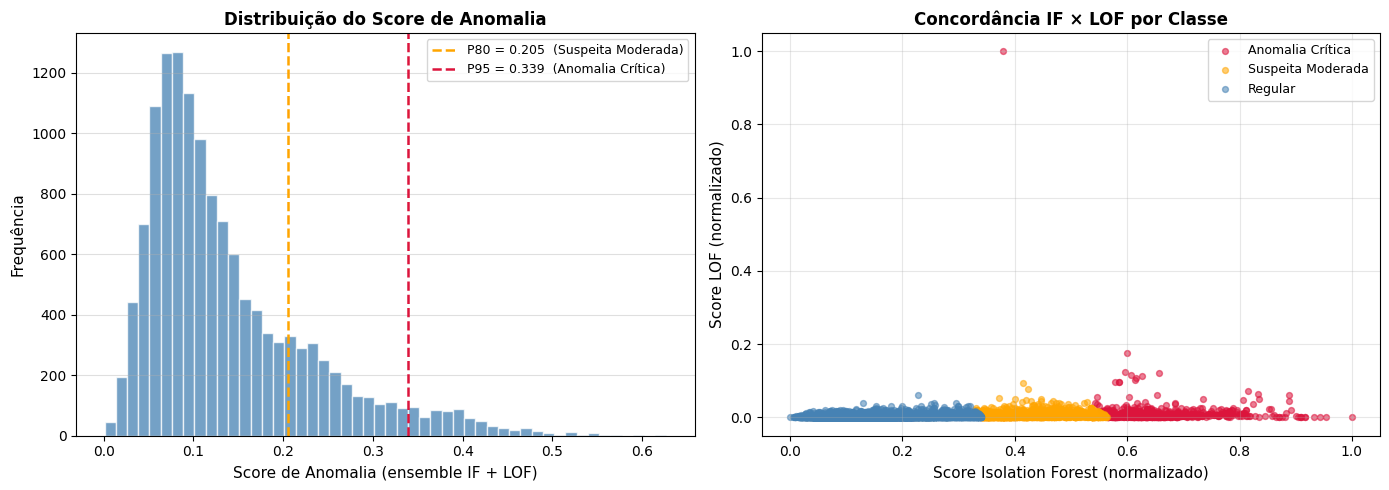

Figura salva: exports/fig_01_score_distribuicao.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Histograma do score ensemble ---
# Mostra como os scores se distribuem e onde os thresholds P80/P95 recaem.
ax1 = axes[0]
ax1.hist(score_ensemble, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax1.axvline(P80, color='orange', linestyle='--', lw=1.8,
            label=f'P80 = {P80:.3f}  (Suspeita Moderada)')
ax1.axvline(P95, color='crimson', linestyle='--', lw=1.8,
            label=f'P95 = {P95:.3f}  (Anomalia Crítica)')
ax1.set_xlabel('Score de Anomalia (ensemble IF + LOF)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição do Score de Anomalia', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# --- Gráfico 2: Dispersão IF × LOF ---
# Mostra a concordância entre os dois algoritmos.
# Pontos no canto superior direito (alto em ambos) são os mais robustamente anômalos.
ax2 = axes[1]
cores = {'Anomalia Crítica': 'crimson', 'Suspeita Moderada': 'orange', 'Regular': 'steelblue'}
for classe, cor in cores.items():
    mask_c = clean_df['classificacao'] == classe
    ax2.scatter(
        if_scores_norm[mask_c], lof_scores_norm[mask_c],
        c=cor, alpha=0.55, s=18, label=classe, rasterized=True
    )
ax2.set_xlabel('Score Isolation Forest (normalizado)', fontsize=11)
ax2.set_ylabel('Score LOF (normalizado)', fontsize=11)
ax2.set_title('Concordância IF × LOF por Classe', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_01_score_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: exports/fig_01_score_distribuicao.png')

### 11.2 — Importância das Features

Utilizamos **Permutation Feature Importance**: permutamos aleatoriamente os valores de
uma feature de cada vez e medimos quanto o score médio de anomalia muda.

- **Aumento grande no score** ao permutar → feature importante (o modelo depende dela)
- **Pouca mudança** → feature com menor contribuição

Esta técnica é agnóstica ao algoritmo e funciona com qualquer modelo (Breiman, 2001).

Calculando importância das features (pode demorar alguns segundos)...


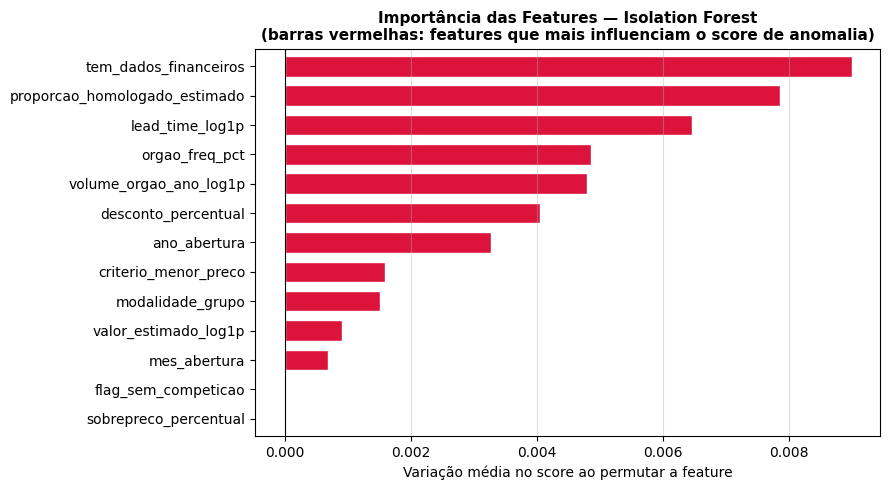

Figura salva: exports/fig_02_feature_importance.png

Feature mais importante: tem_dados_financeiros


In [22]:
def calcular_permutation_importance(model, X, feature_names, n_repeats=15, seed=42):
    """
    Calcula Permutation Feature Importance para o Isolation Forest.

    Para cada feature j:
      1. Salva o score de referência (sem permutação)
      2. Permuta os valores da feature j aleatoriamente
      3. Calcula o novo score médio
      4. A diferença (novo - referência) indica o quanto a feature contribui

    Retorna: Series com importância por feature, ordenada crescentemente
    """
    rng       = np.random.RandomState(seed)
    baseline  = -model.score_samples(X).mean()  # score médio sem permutação
    importancias = []

    for j in range(X.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            rng.shuffle(X_perm[:, j])             # embaralha a coluna j
            score_perm = -model.score_samples(X_perm).mean()
            deltas.append(score_perm - baseline)  # variação do score
        importancias.append(np.mean(deltas))       # média das n_repeats variações

    return pd.Series(importancias, index=feature_names).sort_values(ascending=True)


print('Calculando importância das features (pode demorar alguns segundos)...')
feat_imp = calcular_permutation_importance(iso_forest, X, NOMES_FEATURES, n_repeats=15)

# Visualização: barras vermelhas = features que mais contribuem para o score de anomalia
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white', width=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variação média no score ao permutar a feature', fontsize=10)
ax.set_title('Importância das Features — Isolation Forest\n'
             '(barras vermelhas: features que mais influenciam o score de anomalia)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: exports/fig_02_feature_importance.png')
print(f'\nFeature mais importante: {feat_imp.idxmax()}')

### 11.3 — Top Anomalias Críticas

In [26]:
# Colunas a exibir — filtramos apenas as que existem no DataFrame
cols = [
    'numprocesso', 'ano', 'modalidade', 'orgao',
    'valor_estimado', 'valor_ou_desconto_homologado',
    'lead_time_dias', 'classificacao', 'score_anomalia', 'tipo_anomalia'
]
cols = [c for c in cols if c in anomalias_df.columns]

# Top 20 anomalias críticas ordenadas por score
criticas = (
    anomalias_df[anomalias_df['classificacao'] == 'Anomalia Crítica']
    .sort_values('score_anomalia', ascending=False)
    .head(20)
)
print('=' * 100)
print('TOP ANOMALIAS CRÍTICAS (ordenadas por score)')
print('=' * 100)
display(criticas[cols])

# Top 10 suspeitas moderadas
suspeitas = (
    anomalias_df[anomalias_df['classificacao'] == 'Suspeita Moderada']
    .sort_values('score_anomalia', ascending=False)
    .head(10)
)
print('\n' + '=' * 100)
print('TOP 10 SUSPEITAS MODERADAS')
print('=' * 100)
display(suspeitas[cols])

TOP ANOMALIAS CRÍTICAS (ordenadas por score)


,numprocesso,ano,modalidade,orgao,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
8871,1588,2022,Pregão Eletrônico,UEM-Universidade Estadual de Maringá,"13,985,901.00",NaN,0.00,Anomalia Crítica,0.63,Outro
13521,3,2020,Solicitação de Manifestação de Interesse,DER-Departamento de Estradas de Rodagem do Estado do Paraná,100.00,"350,036,991.00",411.00,Anomalia Crítica,0.60,Sobrepreço
7319,2,2022,Convite,IDR-Instituto de Desenvolvimento Rural do Paraná - IAPAR-EMATER,"45,150.00","5,651,100.00",3.00,Anomalia Crítica,0.57,Sobrepreço
2020,7,2024,Convite,IDR-Instituto de Desenvolvimento Rural do Paraná - IAPAR-EMATER,"7,395.00","51,293,400.00",43.00,Anomalia Crítica,0.57,Sobrepreço
4612,11,2023,Convite,IDR-Instituto de Desenvolvimento Rural do Paraná - IAPAR-EMATER,"16,200.00","119,379,050.00",50.00,Anomalia Crítica,0.56,Sobrepreço
216,2,2025,Leilão,SEAP-Secretaria de Estado da Administração e da Previdência,"34,535,600.00","108,075,600.00",23.00,Anomalia Crítica,0.56,Sobrepreço
1958,219,2024,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,100.00,"14,890,000,000.00",100.00,Anomalia Crítica,0.55,Sobrepreço
1999,263,2024,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,100.00,"26,780,000,000.00",97.00,Anomalia Crítica,0.55,Sobrepreço
2045,1,2024,Leilão,DETRAN-Departamento de Trânsito do Estado do Paraná,"64,567,200.00","157,543,968.00",61.00,Anomalia Crítica,0.55,Sobrepreço
1926,183,2024,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,100.00,"51,423,002,000.00",76.00,Anomalia Crítica,0.55,Sobrepreço



TOP 10 SUSPEITAS MODERADAS


,numprocesso,ano,modalidade,orgao,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
4669,2,2023,Licitação Eletrônica - Estatal,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,"64,555,000.00","25,000,000.00",149.00,Suspeita Moderada,0.34,Desconto Atípico
150,118,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,"2,524,790,625.00",NaN,0.00,Suspeita Moderada,0.34,Modalidade Incomum
9915,102,2021,Concorrência Pública,AMEP-Agência de Assuntos Metropolitanos do Paraná (Antigo COMEC),"1,400,897,500.00","1,256,847,284.00",172.00,Suspeita Moderada,0.34,Modalidade Incomum
131,90,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,NaN,NaN,0.00,Suspeita Moderada,0.34,Valor Estimado Atípico
13400,1532,2020,Pregão Eletrônico,SESA-FUNSAUDE-Fundo Estadual de Saúde do Paraná - FUNSAUDE,"94,060,000.00","699,736,800.00",48.00,Suspeita Moderada,0.34,Sobrepreço
4461,54,2023,Concorrência Eletrônica (Lei Federal 14.133/2021),UNIOESTE FOZ-Universidade Estadual do Oeste do Paraná - Campus Foz do Iguaçu,"39,463,797.00",NaN,9.00,Suspeita Moderada,0.34,Modalidade Incomum
13172,1253,2020,Pregão Eletrônico,FERROESTE-Estrada de Ferro Paraná Oeste S.A.,NaN,NaN,0.00,Suspeita Moderada,0.34,Valor Estimado Atípico
141,105,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),DER-Departamento de Estradas de Rodagem do Estado do Paraná,"2,311,089,089.00",NaN,0.00,Suspeita Moderada,0.34,Modalidade Incomum
1981,244,2024,Concorrência Eletrônica (Lei Federal 14.133/2021),SECID-Secretaria de Estado das Cidades (Antigo SEDU),"330,613,284.00",NaN,0.00,Suspeita Moderada,0.34,Modalidade Incomum
4429,12,2023,Concorrência Eletrônica (Lei Federal 14.133/2021),FUNDEPAR-Instituto Paranaense de Desenvolvimento Educacional,"1,483,818,961.00",NaN,10.00,Suspeita Moderada,0.34,Modalidade Incomum


---
## 12 — Exportação dos Resultados

In [ ]:
# =============================================================================
# ADICIONA COLUNAS DE INTERPRETAÇÃO AO DATASET COMPLETO
# Mescla o driver_principal e tipo_anomalia calculados para as anomalias
# de volta ao dataset completo (registros regulares recebem NaN nessas colunas).
# =============================================================================
clean_df_export = clean_df.sort_values('score_anomalia', ascending=False).copy()

clean_df_export = clean_df_export.merge(
    anomalias_df[['driver_principal', 'tipo_anomalia', 'z_score_driver']],
    left_index=True, right_index=True, how='left'
)

# =============================================================================
# ARQUIVO 1: Dataset completo com scores e classificações
# Útil para explorar todos os registros e entender a distribuição dos scores.
# =============================================================================
path_completo  = EXPORTS_DIR / 'licitacoes_score_ml.csv'
clean_df_export.to_csv(path_completo, sep=';', index=False)

# =============================================================================
# ARQUIVO 2: Apenas as anomalias (Críticas + Suspeitas)
# Arquivo focado para revisão manual por auditores.
# =============================================================================
path_anomalias = EXPORTS_DIR / 'licitacoes_anomalias_ml.csv'
anomalias_df.sort_values('score_anomalia', ascending=False).to_csv(
    path_anomalias, sep=';', index=False
)

print('✓ Arquivos exportados:')
print(f'  {path_completo.name}:  {len(clean_df_export):,} registros')
print(f'  {path_anomalias.name}: {len(anomalias_df):,} registros')
print()
display({
    'TI completo (com scores)': FileLink(path_completo),
    'Somente anomalias':        FileLink(path_anomalias)
})

✓ Arquivos exportados:
  licitacoes_ti_com_score_ml.csv:  13,536 registros
  licitacoes_ti_anomalias_ml.csv: 2,708 registros



{'TI completo (com scores)': /Users/azevedo/GitHub/anomalyClassifier/exports/licitacoes_ti_com_score_ml.csv,
 'Somente anomalias': /Users/azevedo/GitHub/anomalyClassifier/exports/licitacoes_ti_anomalias_ml.csv}

---
## 13 — Sumário Final e Limitações

In [ ]:
n_criticas  = (clean_df['classificacao'] == 'Anomalia Crítica').sum()
n_suspeitas = (clean_df['classificacao'] == 'Suspeita Moderada').sum()
n_regular   = (clean_df['classificacao'] == 'Regular').sum()
n_total     = len(clean_df)

ano_min = clean_df['dataabertura'].min().year
ano_max = clean_df['dataabertura'].max().year

print('=' * 72)
print(' SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES')
print('=' * 72)
print(f'  Total de registros (geral) : {len(clean_df):,}')
print(f'  Registros                  : {n_total:,}')
print(f'  Anomalias Críticas         : {n_criticas:,}  ({n_criticas/n_total*100:.1f}%)')
print(f'  Suspeitas Moderadas        : {n_suspeitas:,}  ({n_suspeitas/n_total*100:.1f}%)')
print(f'  Regulares                  : {n_regular:,}  ({n_regular/n_total*100:.1f}%)')
print()
print(' METODOLOGIA')
print(f'  Algoritmos    : Isolation Forest (Liu et al., 2008)')
print(f'                  + Local Outlier Factor (Breunig et al., 2000)')
print(f'  Ensemble      : {PESO_IF:.0%} IF + {PESO_LOF:.0%} LOF')
print(f'  Threshold P95 : score ≥ {P95:.4f} → Anomalia Crítica')
print(f'  Threshold P80 : score ≥ {P80:.4f} → Suspeita Moderada')
print(f'  Features ({len(NOMES_FEATURES)})  : {NOMES_FEATURES}')
print()
print(' LIMITAÇÕES')
print('  1. SEM RÓTULOS: impossível calcular precisão/recall sem ground truth.')
print('     → Os resultados indicam DESVIO ESTATÍSTICO, não confirmação de fraude.')
print('     → Registros anômalos requerem revisão manual por auditores competentes.')
print()
print('  2. COMPLETUDE FINANCEIRA: registros sem valor_estimado têm features parciais.')
print('     → A feature tem_dados_financeiros explicita isso ao modelo.')
print()
print('  3. FILTRO DE TI: keywords podem capturar falsos positivos ou perder registros.')
print('     → Recomenda-se revisão periódica da lista de palavras-chave.')
print()
print('  4. ESCOPO: dados de licitações do Estado do Paraná (2020–2025).')
print('     → A generalização para outros estados requer revalidação do modelo.')
print('=' * 72)

 SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES DE TI
  Total de registros (geral) : 13,536
  Registros de TI            : 13,536
  Anomalias Críticas         : 677  (5.0%)
  Suspeitas Moderadas        : 2,031  (15.0%)
  Regulares                  : 10,828  (80.0%)

 METODOLOGIA
  Algoritmos    : Isolation Forest (Liu et al., 2008)
                  + Local Outlier Factor (Breunig et al., 2000)
  Ensemble      : 60% IF + 40% LOF
  Threshold P95 : score ≥ 0.3390 → Anomalia Crítica
  Threshold P80 : score ≥ 0.2053 → Suspeita Moderada
  Features (13)  : ['valor_estimado_log1p', 'proporcao_homologado_estimado', 'sobrepreco_percentual', 'desconto_percentual', 'tem_dados_financeiros', 'lead_time_log1p', 'mes_abertura', 'ano_abertura', 'criterio_menor_preco', 'flag_sem_competicao', 'modalidade_grupo', 'orgao_freq_pct', 'volume_orgao_ano_log1p']

 LIMITAÇÕES
  1. SEM RÓTULOS: impossível calcular precisão/recall sem ground truth.
     → Os resultados indicam DESVIO ESTATÍSTICO, não confirmação d